# Arccos On-Course Analysis

End-to-end analysis of your shot-tracked rounds from Arccos. Anchored to the data
pulled by `chrisdecali/golf-reports` into `~/golf-data/` and loaded via
`arccos.loader.load_arccos`.

Four sections:

1. **Strokes gained by category over time** — where are you actually losing strokes,
   and is the trend improving?
2. **Club carry & dispersion on-course** — what each club really carries when it
   counts, compared to your GC3 range data + the forecasted targets.
3. **Course-management decisions** — driver vs 3W off the tee, approach SG by
   distance bucket. Where execution ends and decision-making begins.
4. **Practice priorities** — strokes lost per round per category, translated
   into where one hour of practice buys you the most.

> **Provenance note**: Arccos category SG (`sg_*_arccos`) is the authoritative
> "vs scratch" number. Per-shot SG (`sg_shot_approx`) is reconstructed from a
> published Broadie baseline — directionally accurate, but don't read individual
> shots like the gospel.

In [1]:
# --- Setup ---------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from arccos import load_arccos

# Repo-style: make matplotlib readable in dark/light themes alike.
plt.rcParams.update({"figure.figsize": (10, 4), "figure.dpi": 110,
                     "axes.grid": True, "grid.alpha": 0.3})

data = load_arccos()
print(data.summary())

Arccos store: C:\Users\zfreitas\golf-data
  rounds:   50  date range 2023-08-10 to 2026-06-26
  holes:   599
  shots:  3012  GPS=yes
  clubs:    39


## 1. Strokes gained by category over time

Each row in `rounds_summary.csv` carries Arccos's measured SG vs scratch for
off-tee, approach, short game, putting, and total. Below: per-category mean
across all rounds, plus a rolling-5-round trend so you can see if the most
recent stretch is better or worse than the long-term average.

In [2]:
SG_COLS = ["sg_off_tee_arccos", "sg_approach_arccos",
           "sg_short_arccos", "sg_putting_arccos", "sg_total_arccos"]
SG_LABELS = {
    "sg_off_tee_arccos": "Off-tee",
    "sg_approach_arccos": "Approach",
    "sg_short_arccos": "Short game",
    "sg_putting_arccos": "Putting",
    "sg_total_arccos": "Total",
}

r = data.rounds.sort_values("date").reset_index(drop=True)

overall = r[SG_COLS].mean().rename(SG_LABELS).round(2)
recent = r.tail(10)[SG_COLS].mean().rename(SG_LABELS).round(2)
out = pd.concat({"All rounds": overall, "Last 10 rounds": recent}, axis=1)
out["Delta (last 10 vs all)"] = (out["Last 10 rounds"] - out["All rounds"]).round(2)
out

,All rounds,Last 10 rounds,Delta (last 10 vs all)
Off-tee,-3.84,-3.73,0.11
Approach,-5.79,-6.02,-0.23
Short game,-2.45,-1.81,0.64
Putting,-3.10,-1.58,1.52
Total,-15.11,-13.15,1.96


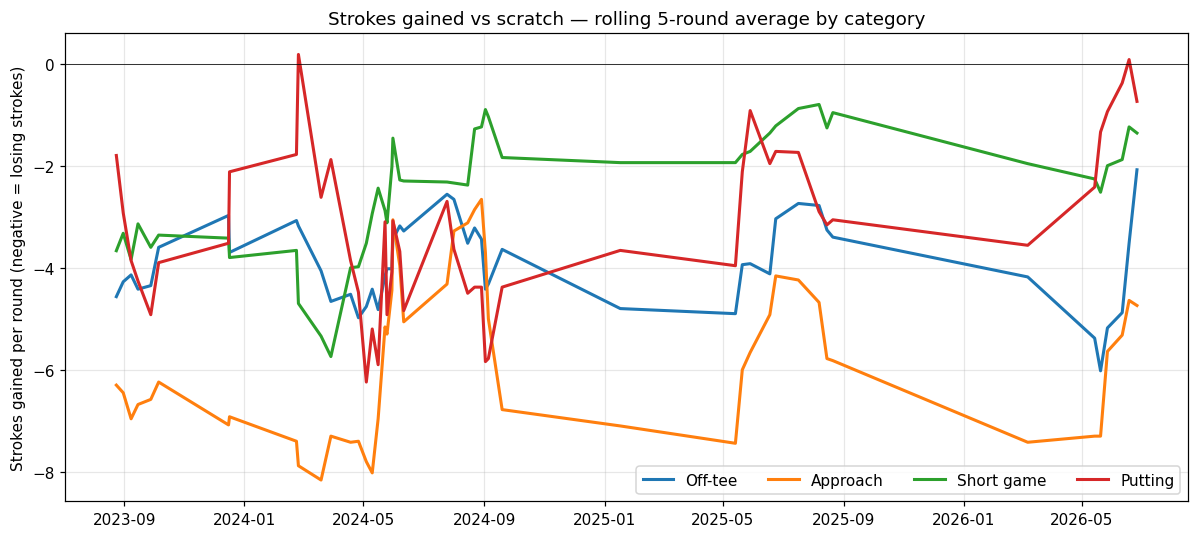

In [3]:
# Rolling-5-round trend in each category. Negative = losing strokes vs scratch.
fig, ax = plt.subplots(figsize=(11, 5))
for col in SG_COLS[:-1]:  # skip total — it's the sum
    series = r[col].rolling(5, min_periods=3).mean()
    ax.plot(r["date"], series, label=SG_LABELS[col], linewidth=2)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Strokes gained vs scratch — rolling 5-round average by category")
ax.set_ylabel("Strokes gained per round (negative = losing strokes)")
ax.legend(loc="lower right", ncol=4)
plt.tight_layout()
plt.show()

## 2. Club carry & dispersion on-course

What each club actually carries when it matters. Sources Arccos's `shot_distance_yd`
per shot, drops putts, and reports the median + 80% band per club. Then sits the
on-course median next to your launch-monitor median and the forecasted target.

In [4]:
def per_club_distance(shots: pd.DataFrame, min_count: int = 6) -> pd.DataFrame:
    # Per-club shot-distance stats from Arccos shots.csv.
    # Filters out putts and zero-distance rows. min_count guards against clubs
    # used so rarely they do not generalize (5+ per upstream README).
    s = shots[~shots["is_putt"].astype(bool) & (shots["shot_distance_yd"] > 0)]
    g = s.groupby("club")["shot_distance_yd"]
    out = pd.DataFrame({
        "shots": g.size(),
        "median": g.median().round(0),
        "p20": g.quantile(0.2).round(0),
        "p80": g.quantile(0.8).round(0),
    })
    out["80% band"] = (out["p80"] - out["p20"]).round(0)
    out = out[out["shots"] >= min_count].sort_values("median", ascending=False)
    return out

clubs_on_course = per_club_distance(data.shots)
clubs_on_course

,shots,median,p20,p80,80% band
club,,,,,
Driver,427,195.0,162.0,215.0,53.0
3 Wood,71,164.0,96.0,196.0,100.0
Club 16,21,158.0,102.0,171.0,69.0
5 Wood,71,156.0,112.0,184.0,72.0
Club 35,119,150.0,95.0,178.0,83.0
Hybrid,129,137.0,97.0,158.0,61.0
5 Iron,34,136.0,93.0,154.0,61.0
6 Iron,77,129.0,96.0,140.0,44.0
Club 38,11,126.0,120.0,143.0,23.0


In [5]:
# Side-by-side with your forecast and GC3 measured (where available).
# The forecast CSV was built by forecast_club_distances.py (see repo root).
try:
    forecast = pd.read_csv("realistic_club_distances.csv")
    # Map forecast labels (e.g. "7i (33 deg)") to Arccos labels (e.g. "7 Iron").
    label_map = {
        "Dr": "Driver", "3w": "3 Wood", "3h": "Hybrid", "4h": "Hybrid",
        "5i": "5 Iron", "6i": "6 Iron", "7i": "7 Iron", "8i": "8 Iron",
        "9i": "9 Iron", "PW": "Pitching Wedge",
    }
    forecast["arccos_club"] = forecast["Club"].str.split(" ").str[0].map(label_map)
    f = forecast.dropna(subset=["arccos_club"]).set_index("arccos_club")
    comp = clubs_on_course.join(f[["Carry now (yd)", "Carry target (yd)"]], how="left")
    comp = comp.rename(columns={"median": "On-course median",
                                "Carry now (yd)": "Forecast (anchored to GC3)",
                                "Carry target (yd)": "Achievable target"})
    comp["Delta vs forecast"] = (comp["On-course median"] - comp["Forecast (anchored to GC3)"]).round(0)
    display_cols = ["shots", "On-course median", "Forecast (anchored to GC3)",
                    "Delta vs forecast", "Achievable target", "80% band"]
    comp[display_cols]
except FileNotFoundError:
    print("realistic_club_distances.csv not found — run forecast_club_distances.py first.")
    clubs_on_course

**How to read this**: a negative `Delta vs forecast` means on-course is shorter
than the GC3-anchored forecast — totally normal (lies, weather, less than 100%
swings). A wide `80% band` means dispersion is hurting you on that club; a narrow
band means you trust it. Compare across clubs to find the unreliable ones.

## 3. Course-management decisions

Two questions:

- **Driver vs 3-wood off the tee** — which actually saves you strokes? Compares
  per-shot SG when you grab the driver vs your most-used backup tee club.
- **Approach SG by distance bucket** — where on the course do approach shots
  bleed strokes most? Surfaces the "I never hit it close from 150" pattern.

In [6]:
# 3a. Tee-club selection
tee_shots = data.shots[data.shots["is_tee"].astype(bool)].copy()
tee_club_sg = (tee_shots.groupby("club")
               .agg(shots=("sg_shot_approx", "size"),
                    avg_sg=("sg_shot_approx", "mean"),
                    median_dist=("shot_distance_yd", "median"))
               .sort_values("shots", ascending=False))
tee_club_sg = tee_club_sg[tee_club_sg["shots"] >= 5]
tee_club_sg["avg_sg"] = tee_club_sg["avg_sg"].round(3)
tee_club_sg["median_dist"] = tee_club_sg["median_dist"].round(0)
tee_club_sg

,shots,avg_sg,median_dist
club,,,
Driver,426,-0.300,195.0
Hybrid,37,-0.447,151.0
6 Iron,31,-0.446,131.0
7 Iron,17,-0.540,118.0
8 Iron,14,-0.255,118.0
5 Iron,14,-0.689,144.0
Club 35,12,-0.667,134.0
Wedge,11,-0.347,75.0
Pitching Wedge,9,-0.423,109.0


In [7]:
# 3b. Approach SG by distance bucket. Pin distance at shot start is what matters.
approach_shots = data.shots[(data.shots["category_approx"] == "approach") &
                            (data.shots["start_dist_to_pin_yd"].notna())].copy()
buckets = [0, 50, 75, 100, 125, 150, 175, 200, 250, 999]
labels = ["<50", "50-75", "75-100", "100-125", "125-150",
          "150-175", "175-200", "200-250", "250+"]
approach_shots["bucket"] = pd.cut(approach_shots["start_dist_to_pin_yd"],
                                  bins=buckets, labels=labels, right=False)
approach_by_bucket = (approach_shots.groupby("bucket", observed=True)
                      .agg(shots=("sg_shot_approx", "size"),
                           avg_sg=("sg_shot_approx", "mean"),
                           median_proximity=("end_dist_to_pin_yd", "median"))
                      .round(2))
approach_by_bucket

,shots,avg_sg,median_proximity
bucket,,,
<50,131,-0.23,9.9
50-75,94,-0.15,10.7
75-100,90,-0.25,16.0
100-125,148,-0.33,17.9
125-150,175,-0.42,24.4
150-175,127,-0.41,28.7
175-200,62,-0.32,46.1
200-250,55,-0.27,76.6
250+,142,-0.23,154.9


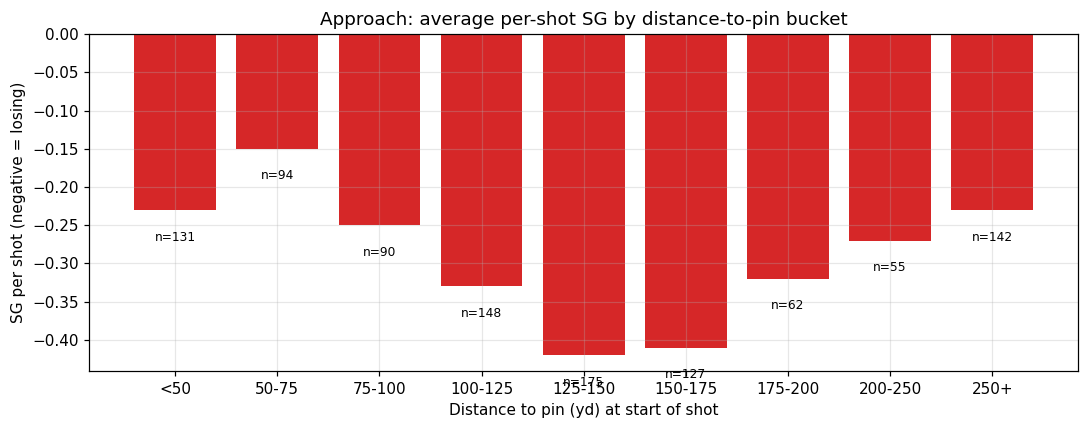

In [8]:
# Visualize approach SG by distance bucket — green = saving strokes, red = losing.
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#2ca02c" if v >= 0 else "#d62728" for v in approach_by_bucket["avg_sg"]]
ax.bar(approach_by_bucket.index.astype(str), approach_by_bucket["avg_sg"], color=colors)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Approach: average per-shot SG by distance-to-pin bucket")
ax.set_ylabel("SG per shot (negative = losing)")
ax.set_xlabel("Distance to pin (yd) at start of shot")
for i, (n, v) in enumerate(zip(approach_by_bucket["shots"], approach_by_bucket["avg_sg"])):
    ax.text(i, v + (0.02 if v >= 0 else -0.04), f"n={n}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

## 4. Practice priorities

For each category, compute **strokes lost per round vs scratch** and **rank**.
The biggest negative is where one hour of practice buys you the most. A rough
practice-time allocation is suggested proportional to strokes-lost — feel free
to weight by what you actually enjoy practicing.

In [9]:
priorities = (data.rounds[SG_COLS[:-1]].mean()
              .rename(SG_LABELS).rename("Avg SG per round")
              .to_frame())
priorities["Strokes LOST per round"] = (-priorities["Avg SG per round"]).clip(lower=0)
total_lost = priorities["Strokes LOST per round"].sum()
if total_lost > 0:
    priorities["Practice-time share"] = (
        (priorities["Strokes LOST per round"] / total_lost * 100).round(0)
        .astype(int).astype(str) + " %"
    )
else:
    priorities["Practice-time share"] = "—"
priorities = priorities.sort_values("Strokes LOST per round", ascending=False)
priorities

,Avg SG per round,Strokes LOST per round,Practice-time share
Approach,-5.790000,5.790000,38 %
Off-tee,-3.836735,3.836735,25 %
Putting,-3.102000,3.102000,20 %
Short game,-2.450000,2.450000,16 %


### Practice translation

- **Strokes lost per round** is what each category costs you vs scratch — this is
  what to *fix*, not just what to *practice the most*.
- **Practice-time share** is purely proportional to strokes lost. Treat it as a
  starting point: a category you enjoy practicing is one you'll actually
  practice, which compounds into improvement faster than the optimal split
  you abandon after a week.
- **Cross-reference with Section 2** — if approach is your biggest leak AND your
  on-course 7i carry is 7 yd shorter than your range carry, the gap isn't
  swing speed, it's strike consistency under pressure. That's a range-session
  fix (which the GC3 notebook already flagged: spin too low, smash too low).